## Ant Traffic Model

The **Ant Traffic Model** is a one-dimensional agent-based simulation that studies the collective movement of ants along a trail. Each lattice site can be occupied by at most one ant, and ants move forward according to local traffic conditions and pheromone signals. The model captures how simple local interactions can produce complex emergent phenomena such as traffic flow, clustering, and self-organization.

### Model Description

- The trail is represented by a one-dimensional lattice of length \(L\).
- A fraction \($\rho$\) of the lattice sites is initially occupied by ants.
- Each site stores two variables:
  - **Ant occupancy** (occupied or empty)
  - **Pheromone presence** (present or absent)
- During each Monte Carlo step, ants attempt to move one lattice site forward.
- The hopping probability depends on whether pheromone exists at the target site:
  - \(Q\): hopping probability if pheromone is present.
  - \(q\): hopping probability if pheromone is absent, where typically \(Q > q\).
- Pheromones evaporate with probability \(f\), producing a dynamic feedback between ant motion and the trail.

### Parameters

| Parameter | Description |
|-----------|-------------|
| \(L\) | Length of the lattice |
| \($\rho\$) | Ant density |
| \(Q\) | Hopping probability with pheromone |
| \(q\) | Hopping probability without pheromone |
| \(f\) | Pheromone evaporation probability |
| `steps` | Total simulation time |
| `burn` | Burn-in period before measurements |

### Simulation Procedure

1. Initialize ants randomly according to the density \($\rho\$).
2. Initialize the pheromone field.
3. Update ant positions using the stochastic hopping rules.
4. Deposit pheromone on occupied sites.
5. Evaporate pheromone with probability \(f\).
6. Repeat the process for the desired number of Monte Carlo steps.
7. After the burn-in period, compute observables such as average velocity, particle current, and density profiles.

### Exact Solution for $f=0$

In the special case of **zero pheromone evaporation** ($f=0$), every site that has been visited by an ant retains pheromone indefinitely. After a transient period, the entire lattice becomes permanently covered with pheromone. Consequently, every ant hops with the same probability $Q$, and the ant-traffic model reduces exactly to the **Totally Asymmetric Simple Exclusion Process (TASEP)** with parallel update.

The exact stationary current is given by

$$
J=\frac{1}{2}\left(1-\sqrt{1-4Q\rho(1-\rho)}\right),
$$

where $Q$ is the hopping probability and $\rho=N/L$ is the ant density.

The corresponding average velocity is

$$
v=\frac{J}{\rho}
=
\frac{1-\sqrt{1-4Q\rho(1-\rho)}}{2\rho}.
$$

For small hopping probabilities ($Q\ll1$), the square root can be expanded as

$$
\sqrt{1-4Q\rho(1-\rho)}
\simeq
1-2Q\rho(1-\rho),
$$

which yields

$$
J \simeq Q\rho(1-\rho),
$$

recovering the well-known mean-field expression.

In the deterministic limit ($Q=1$), the current simplifies to

$$
J=
\frac{1}{2}\left(1-|1-2\rho|\right),
$$

or equivalently,

$$
J=
\begin{cases}
\rho, & \rho\le \dfrac12,\\[2mm]
1-\rho, & \rho\ge \dfrac12.
\end{cases}
$$

This piecewise linear current-density relation represents the exact fundamental diagram of the deterministic parallel-update TASEP and corresponds to the $f=0$ limit of the ant-traffic model.
### Objective

The purpose of this model is to investigate how pheromone-mediated interactions influence collective transport, traffic flow, and self-organization in ant colonies. Despite its simple microscopic rules, the model exhibits rich dynamical behavior, including free-flow motion, traffic jams, and density-dependent phase transitions.

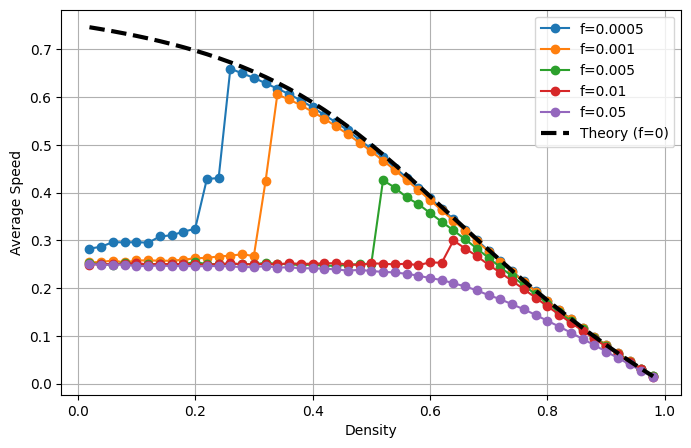

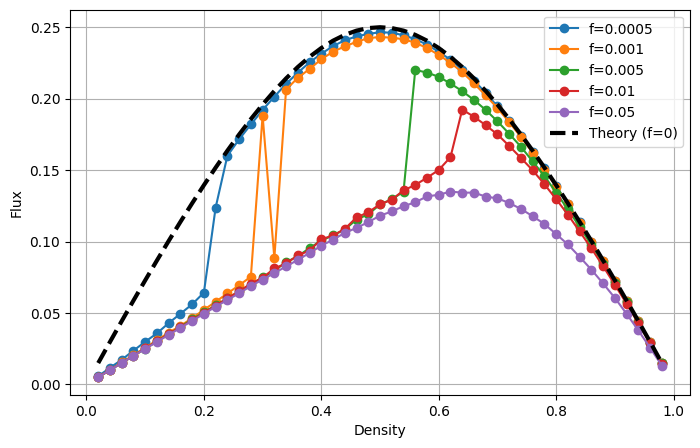

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# =====================================================
# One simulation
# =====================================================

@njit
def simulate(L, rho, Q, q, f, steps, burn):

    N = int(rho * L)

    # -----------------------
    # Initial configuration
    # -----------------------

    ant = np.zeros(L, np.int8)
    pher = np.zeros(L, np.int8)

    pos = np.random.permutation(L)[:N]

    for p in pos:
        ant[p] = 1
        pher[p] = 1

    moves = 0
    measurements = 0

    # =================================================
    # Monte Carlo steps
    # =================================================

    for t in range(steps):

        # who will move this step?
        move = np.zeros(L, np.int8)

        # -------------------------
        # Decide moves
        # -------------------------

        for i in range(L):

            if ant[i] == 0:
                continue

            j = (i + 1) % L

            if ant[j] == 1:
                continue

            if pher[j] == 1:
                prob = Q
            else:
                prob = q

            if np.random.random() < prob:
                move[i] = 1

        # -------------------------
        # Parallel update
        # -------------------------

        new_ant = ant.copy()

        step_moves = 0

        for i in range(L):

            if move[i] == 1:

                j = (i + 1) % L

                new_ant[i] = 0
                new_ant[j] = 1

                step_moves += 1

        ant = new_ant

        # -------------------------
        # Pheromone update
        # -------------------------

        new_pher = pher.copy()

        for i in range(L):

            if ant[i] == 1:

                new_pher[i] = 1

            else:

                if pher[i] == 1:

                    if np.random.random() < f:

                        new_pher[i] = 0

        pher = new_pher

        # -------------------------
        # Measurements
        # -------------------------

        if t >= burn:

            moves += step_moves
            measurements += 1

    avg_speed = moves / (N * measurements)

    flux = rho * avg_speed

    return avg_speed, flux


# =====================================================
# Parameters
# =====================================================

L = 1000

Q = 0.75
q = 0.25

steps = 100000
burn = 30000

densities = np.linspace(0.02,0.98,49)

# evaporation probabilities
f_values = [0.0005, 0.001,0.005,0.01,0.05]

# =====================================================
# Speed
# =====================================================

plt.figure(figsize=(8,5))

for f in f_values:

    speed=[]

    for rho in densities:

        v,J = simulate(L,rho,Q,q,f,steps,burn)

        speed.append(v)

    plt.plot(densities,speed,'o-',label=f"f={f}")

# analytical result for f=0
plt.plot(densities, (1 - np.sqrt(1 - 4*Q*densities*(1 - densities)))/(2*densities),
         'k--',lw=3,label='Theory (f=0)')

plt.xlabel("Density")
plt.ylabel("Average Speed")
plt.grid(True)
plt.legend()

plt.show()


# =====================================================
# Flux
# =====================================================

plt.figure(figsize=(8,5))

for f in f_values:

    flux=[]

    for rho in densities:

        v,J = simulate(L,rho,Q,q,f,steps,burn)

        flux.append(J)

    plt.plot(densities,flux,'o-',label=f"f={f}")

plt.plot(densities,
          (1 - np.sqrt(1 - 4*Q*densities*(1 - densities)))/2,
         'k--',
         lw=3,
         label='Theory (f=0)')

plt.xlabel("Density")
plt.ylabel("Flux")
plt.grid(True)
plt.legend()

plt.show()